In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt

In [15]:
gene_dir = Path("/Users/katsiarynadavydzenka/Documents/PhD_AI/nb_stan/results/crc/fits_nb_de/ZNRF3")

ppc = np.load(gene_dir / "ppc_y_rep_thin.npz")

y_rep = ppc["y_rep"]   # shape: (draws, N)
y_obs = ppc["y_obs"]   # shape: (N,)

In [17]:
obs_mean = y_obs.mean()
rep_means = y_rep.mean(axis=1)

obs_var = y_obs.var()
rep_vars = y_rep.var(axis=1)

In [19]:
ppc_p_mean = np.mean(rep_means >= obs_mean)
ppc_p_var  = np.mean(rep_vars >= obs_var)
print(ppc_p_mean, ppc_p_var)

0.45 0.355


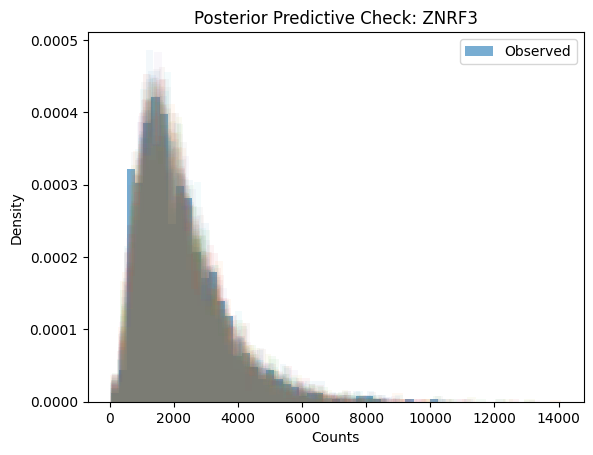

In [21]:
# Distribution PPC plot

plt.hist(y_obs, bins=40, density=True, alpha=0.6, label="Observed")

for i in range(50):
    plt.hist(y_rep[i], bins=40, density=True, alpha=0.05)

plt.legend()
plt.title("Posterior Predictive Check: ZNRF3")
plt.xlabel("Counts")
plt.ylabel("Density")
plt.show()

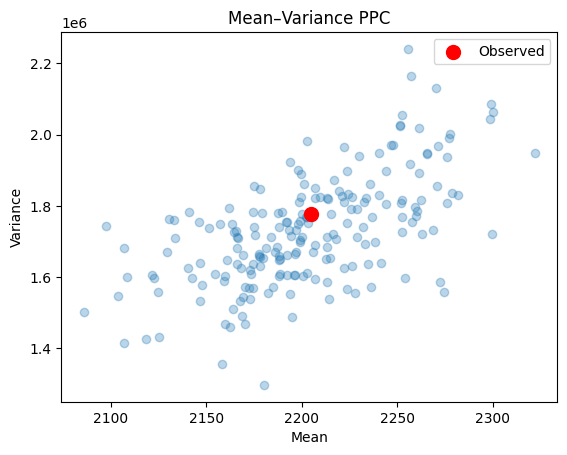

In [23]:
# Mean–variance PPC
plt.scatter(rep_means, rep_vars, alpha=0.3)
plt.scatter(obs_mean, obs_var, color="red", s=100, label="Observed")

plt.xlabel("Mean")
plt.ylabel("Variance")
plt.legend()
plt.title("Mean–Variance PPC")
plt.show()

In [3]:
# Run PPC across all genes
root = Path("/Users/katsiarynadavydzenka/Documents/PhD_AI/nb_stan/results/crc/fits_nb_de")

ppc_results = []

for gene_dir in root.iterdir():
    ppc_file = gene_dir / "ppc_y_rep_thin.npz"

    if not ppc_file.exists():
        continue

    ppc = np.load(ppc_file)
    y_rep = ppc["y_rep"]
    y_obs = ppc["y_obs"]

    obs_mean = y_obs.mean()
    rep_means = y_rep.mean(axis=1)

    obs_var = y_obs.var()
    rep_vars = y_rep.var(axis=1)

    ppc_results.append({
        "gene": gene_dir.name,
        "ppc_p_mean": np.mean(rep_means >= obs_mean),
        "ppc_p_var": np.mean(rep_vars >= obs_var),
    })

ppc_df = pd.DataFrame(ppc_results)

In [5]:
ppc_df.head()

,gene,ppc_p_mean,ppc_p_var
0,CALR,0.290,0.005
1,CHEK2,0.610,0.870
2,BCL9L,0.705,0.740
3,KRAS,0.350,0.400
4,TGFBR2,0.320,0.140


In [7]:
def plot_ppc_diagnostics(ppc_df, bins=50, save_path=None, dpi=300):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

    # Mean statistic p-values
    axes[0].hist(ppc_df["ppc_p_mean"], bins=bins, edgecolor="black", alpha=0.7)
    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].set_title("PPC p-values (Mean statistic)")
    axes[0].set_xlabel("p-value")
    axes[0].set_ylabel("Frequency")

    # Variance statistic p-values
    axes[1].hist(ppc_df["ppc_p_var"], bins=bins, edgecolor="black", alpha=0.7)
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_title("PPC p-values (Variance statistic)")
    axes[1].set_xlabel("p-value")

    n = len(ppc_df)
    expected = n / bins
    axes[0].axhline(expected, linestyle="--", color="red", label="Uniform expectation")
    axes[0].legend()
    axes[1].axhline(expected, linestyle="--", color="red")

    fig.suptitle("Posterior Predictive Check Diagnostics", fontsize=14)
    plt.tight_layout()

    # Save figure if path provided
    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

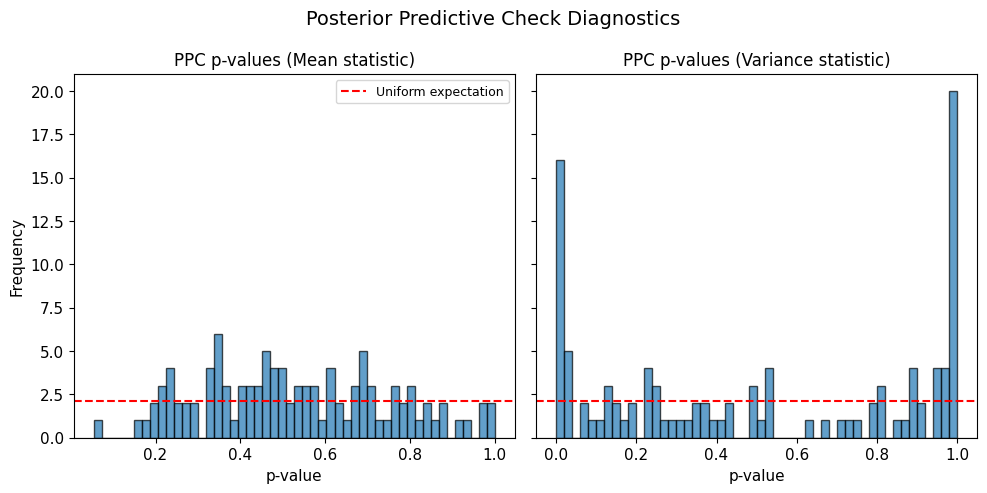

In [127]:
plot_ppc_diagnostics(ppc_df, 
                     save_path="/Users/katsiarynadavydzenka/Documents/PhD_AI/nb_stan/plots/ppc_diagnostics.png")

he model captures expected expression level across genes.

The variance PPP distribution is U-shaped, with mass near 0 or 1.
This indicates some genes are underdispersed and some overdispersed relative to the model.
Conclusion: dispersion modeling is reasonable but imperfect, which is expected.

Does the fitted model reproduce the CN→expression response (and purity effects) that the model is explicitly built to capture?

#### 1) CN-response curves with posterior predictive bands (by subtype)

In [9]:
# Helpers to reconstruct the same per-gene dataframe used in Stan

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9
})

def cn_bin_1_2_3_4p(copies: np.ndarray) -> np.ndarray:
    cn = np.rint(np.asarray(copies, dtype=float)).astype(int)
    return np.clip(cn, 1, 4)

def purity_bin(purity: np.ndarray, edges=(0.0,0.2,0.4,0.6,0.8,1.0)) -> np.ndarray:
    edges = np.asarray(edges, dtype=float)
    p = np.asarray(purity, dtype=float)
    b = np.digitize(p, edges, right=True) - 1
    return np.clip(b, 0, len(edges)-2)

def rebuild_gene_df_for_ppc(df_long: pd.DataFrame, gene: str, subtype_col="subtype",
                            cna="all", et=0.15) -> pd.DataFrame:
    df = df_long[df_long["gene"] == gene].copy()

    if cna == "amp":
        df = df[df["copies"] > (2 - et)]
    elif cna == "del":
        df = df[df["copies"] < (2 + et)]
    elif cna == "all":
        pass
    else:
        raise ValueError("cna must be 'amp', 'del', or 'all'")

    df = df.dropna(subset=["expr", "copies", "purity", "sf", subtype_col]).copy()
    df = df[(df["expr"] >= 0) & (df["sf"] > 0) & (df["purity"].between(0, 1))].copy()

    CN_eff = df["copies"].astype(float).clip(lower=1.0)
    df["dose_log"] = np.log(CN_eff / 2.0)
    df["dev"] = (df["copies"].astype(float) - 2.0) / 2.0
    return df

def load_gene_ppc(gene_dir: Path):
    ppc = np.load(gene_dir / "ppc_y_rep_thin.npz")
    return ppc["y_obs"], ppc["y_rep"]

def load_subtype_levels(gene_dir: Path):
    res = json.loads((gene_dir / "result.json").read_text())
    levels = res.get("subtype_levels")
    if not levels:
        raise ValueError(f"Missing subtype_levels in {gene_dir/'result.json'}")
    return levels

def _ppc_band(values_1d: np.ndarray, q_lo=0.05, q_hi=0.95):
    med = np.nanmedian(values_1d, axis=0)
    lo = np.nanquantile(values_1d, q_lo, axis=0)
    hi = np.nanquantile(values_1d, q_hi, axis=0)
    return lo, med, hi

def save_cn_ppc_figure(gene_dir: Path, df_long: pd.DataFrame, out_png: Path,
                       subtype_col="subtype", cna="all", et=0.15,
                       n_draws_plot=200, q_lo=0.05, q_hi=0.95, use_log1p=True):
    gene = gene_dir.name
    y_obs, y_rep = load_gene_ppc(gene_dir)
    df = rebuild_gene_df_for_ppc(df_long, gene, subtype_col=subtype_col, cna=cna, et=et)

    if len(df) != len(y_obs):
        raise ValueError(f"[{gene}] Row mismatch: df={len(df)} vs y_obs={len(y_obs)}")

    levels = load_subtype_levels(gene_dir)
    subtype_map = {lv: i+1 for i, lv in enumerate(levels)}
    subtype = df[subtype_col].map(subtype_map).astype(int).to_numpy()
    S = len(levels)

    cn = cn_bin_1_2_3_4p(df["copies"].to_numpy())
    cn_bins = [1, 2, 3, 4]
    x = np.arange(len(cn_bins))
    xlabels = ["CN=1", "CN=2", "CN=3", "CN=4+"]

    D = y_rep.shape[0]
    idx = np.linspace(0, D-1, num=min(n_draws_plot, D), dtype=int)
    y_rep = y_rep[idx]

    def tr(y): return np.log1p(y) if use_log1p else y

    obs = tr(y_obs)

    # compute (draws, S, 4) binned means
    rep_stats = np.full((y_rep.shape[0], S, len(cn_bins)), np.nan)
    obs_stats = np.full((S, len(cn_bins)), np.nan)

    for s in range(1, S+1):
        ms = subtype == s
        for j, b in enumerate(cn_bins):
            m = ms & (cn == b)
            if np.any(m):
                obs_stats[s-1, j] = np.mean(obs[m])
                rep_stats[:, s-1, j] = np.mean(tr(y_rep[:, m]), axis=1)

    # plot as multi-panel (one row per subtype)
    fig, axes = plt.subplots(S, 1, figsize=(9, 3*S), sharex=True)
    if S == 1:
        axes = [axes]

    for s in range(S):
        ax = axes[s]
        lo, med, hi = _ppc_band(rep_stats[:, s, :], q_lo=q_lo, q_hi=q_hi)
        ax.fill_between(x, lo, hi, alpha=0.25, label=f"{int((q_hi-q_lo)*100)}% PPC band")
        ax.plot(x, med, marker="o", linewidth=2, label="PPC median")
        ax.plot(x, obs_stats[s, :], marker="o", linewidth=2, label="Observed")
        ax.set_ylabel("mean log1p(y)" if use_log1p else "mean y")
        ax.set_title(levels[s], loc="left", fontsize=10)
        ax.legend(fontsize=8)

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(xlabels)
    fig.suptitle(f"{gene} — CN-response PPC", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    out_png.parent.mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(10,6))
    fig.savefig(out_png, dpi=300)
    plt.close(fig)

def save_purity_ppc_figure(gene_dir: Path, df_long: pd.DataFrame, out_png: Path,
                           subtype_col="subtype", cna="all", et=0.15,
                           purity_edges=(0,0.2,0.4,0.6,0.8,1.0),
                           n_draws_plot=200, q_lo=0.05, q_hi=0.95, use_log1p=True):
    gene = gene_dir.name
    y_obs, y_rep = load_gene_ppc(gene_dir)
    df = rebuild_gene_df_for_ppc(df_long, gene, subtype_col=subtype_col, cna=cna, et=et)

    if len(df) != len(y_obs):
        raise ValueError(f"[{gene}] Row mismatch: df={len(df)} vs y_obs={len(y_obs)}")

    levels = load_subtype_levels(gene_dir)
    subtype_map = {lv: i+1 for i, lv in enumerate(levels)}
    subtype = df[subtype_col].map(subtype_map).astype(int).to_numpy()
    S = len(levels)

    pb = purity_bin(df["purity"].to_numpy(), edges=purity_edges)
    K = len(purity_edges) - 1
    x = np.arange(K)
    xlabels = [f"{purity_edges[i]:.1f}-{purity_edges[i+1]:.1f}" for i in range(K)]

    D = y_rep.shape[0]
    idx = np.linspace(0, D-1, num=min(n_draws_plot, D), dtype=int)
    y_rep = y_rep[idx]

    def tr(y): return np.log1p(y) if use_log1p else y

    obs = tr(y_obs)

    rep_stats = np.full((y_rep.shape[0], S, K), np.nan)
    obs_stats = np.full((S, K), np.nan)

    for s in range(1, S+1):
        ms = subtype == s
        for k in range(K):
            m = ms & (pb == k)
            if np.any(m):
                obs_stats[s-1, k] = np.mean(obs[m])
                rep_stats[:, s-1, k] = np.mean(tr(y_rep[:, m]), axis=1)

    fig, axes = plt.subplots(S, 1, figsize=(9, 3*S), sharex=True)
    if S == 1:
        axes = [axes]

    for s in range(S):
        ax = axes[s]
        lo, med, hi = _ppc_band(rep_stats[:, s, :], q_lo=q_lo, q_hi=q_hi)
        ax.fill_between(x, lo, hi, alpha=0.25, label=f"{int((q_hi-q_lo)*100)}% PPC band")
        ax.plot(x, med, marker="o", linewidth=2, label="PPC median")
        ax.plot(x, obs_stats[s, :], marker="o", linewidth=2, label="Observed")
        ax.set_ylabel("mean log1p(y)" if use_log1p else "mean y")
        ax.set_title(levels[s], loc="left", fontsize=10)
        ax.legend(fontsize=8)

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(xlabels, rotation=25, ha="right")
    fig.suptitle(f"{gene} — Purity-response PPC", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    out_png.parent.mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(10,6))
    fig.savefig(out_png, dpi=300)
    plt.close(fig)

In [11]:
# Assemble a 2-page PDF report (Page 1 CN, Page 2 Purity)

from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from reportlab.lib.units import inch
from reportlab.lib.utils import ImageReader

def make_two_page_ppc_report(pdf_path: str | Path,
                            cn_pngs: list[Path],
                            purity_pngs: list[Path],
                            title_cn="Posterior Predictive Check — CN-response",
                            title_purity="Posterior Predictive Check — Purity-response",
                            ncols=1, margin=0.6*inch):
    pdf_path = Path(pdf_path)
    pdf_path.parent.mkdir(parents=True, exist_ok=True)

    W, H = letter
    c = canvas.Canvas(str(pdf_path), pagesize=letter)

    def draw_page(title, pngs):
        c.setFont("Helvetica-Bold", 16)
        c.drawString(margin, H - margin + 0.05*inch, title)

        # grid geometry
        n = len(pngs)
        ncols_local = ncols
        nrows_local = int(np.ceil(n / ncols_local)) if n > 0 else 1

        usable_w = W - 2*margin
        usable_h = H - 2*margin - 0.4*inch  # space for title
        cell_w = usable_w / ncols_local
        cell_h = usable_h / nrows_local

        for i, p in enumerate(pngs):
            r = i // ncols_local
            col = i % ncols_local

            x0 = margin + col * cell_w
            y0 = H - margin - 0.4*inch - (r+1)*cell_h

            # inset padding inside cell
            pad = 0.08*inch
            x = x0 + pad
            y = y0 + pad
            w = cell_w - 2*pad
            h = cell_h - 2*pad

            img = ImageReader(str(p))
            c.drawImage(img, x, y, width=w, height=h, preserveAspectRatio=True, anchor='c')

        c.showPage()

    draw_page(title_cn, cn_pngs)
    draw_page(title_purity, purity_pngs)
    c.save()

def build_ppc_report_for_genes(
    fit_root: str | Path,
    df_long: pd.DataFrame,
    genes: list[str],
    out_dir: str | Path,
    subtype_col="subtype",
    cna="all",
    et=0.15,
):
    fit_root = Path(fit_root)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    cn_pngs = []
    purity_pngs = []

    for g in genes:
        gdir = fit_root / g
        if not (gdir / "ppc_y_rep_thin.npz").exists():
            print(f"Skipping {g}: no ppc_y_rep_thin.npz")
            continue

        cn_png = out_dir / f"{g}_cn_ppc.png"
        purity_png = out_dir / f"{g}_purity_ppc.png"

        save_cn_ppc_figure(gdir, df_long, cn_png, subtype_col=subtype_col, cna=cna, et=et)
        save_purity_ppc_figure(gdir, df_long, purity_png, subtype_col=subtype_col, cna=cna, et=et)

        cn_pngs.append(cn_png)
        purity_pngs.append(purity_png)

    pdf_path = out_dir / "ppc_report.pdf"
    make_two_page_ppc_report(pdf_path, cn_pngs, purity_pngs)
    print("Saved:", pdf_path)

In [13]:
DATA_PATH = "/Users/katsiarynadavydzenka/Documents/PhD_AI/nb_stan/CRC/data/stan_model_test/"
df_long = pd.read_csv(os.path.join(DATA_PATH, "crc_joint_long_de_drivers.csv"))
df_long.head()

,gene,sampleID,expr,copies,subtype,purity,ploidy,sf
0,ACVR1B,CRC.SW.U0001.T,7593,2,MSS,0.41,3.8,1.293201
1,ACVR1B,CRC.SW.U0002.T,5003,2,MSS,0.37,3.3,1.024008
2,ACVR1B,CRC.SW.U0004.T,4994,2,MSS,0.58,3.2,1.169870
3,ACVR1B,CRC.SW.U0030.T,6231,2,MSS,0.59,2.2,1.290047
4,ACVR1B,CRC.SW.U0066.T,2908,2,MSS,0.41,1.9,0.971163


In [15]:
FIT_ROOT = "/Users/katsiarynadavydzenka/Documents/PhD_AI/nb_stan/results/crc/fits_nb_de"   # contains gene folders: APC/, SMAD4/, ZNRF3/...
OUT_DIR  = "/Users/katsiarynadavydzenka/Documents/PhD_AI/nb_stan/plots"

#genes = ["SMAD4", "ZNRF3", "APC", "LILRB3"]  
genes = ["ASXL1", "ERBB2", "SMAD4", "BCOR", "JUN"]
build_ppc_report_for_genes(FIT_ROOT, 
                           df_long, 
                           genes, 
                           OUT_DIR)

/var/folders/mh/vvy722dj18x7xj41n2qbdzs80000gn/T/ipykernel_3610/316351380.py:53: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(values_1d, axis=0)
/opt/anaconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
/var/folders/mh/vvy722dj18x7xj41n2qbdzs80000gn/T/ipykernel_3610/316351380.py:53: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(values_1d, axis=0)
/opt/anaconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
/var/folders/mh/vvy722dj18x7xj41n2qbdzs80000gn/T/ipykernel_3610/316351380.py:53: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(values_1d, axis=0)
/opt/anaconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
/var/folders/mh/vvy722dj18x7xj41n2qbdzs80000gn/T/ipy

Saved: /Users/katsiarynadavydzenka/Documents/PhD_AI/nb_stan/plots/ppc_report.pdf


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

...

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [129]:
# Compute PPC statistics

def compute_ppc_stats(y_obs, y_rep):

    rep_means = y_rep.mean(axis=1)
    rep_vars = y_rep.var(axis=1)

    obs_mean = y_obs.mean()
    obs_var = y_obs.var()

    p_mean = np.mean(rep_means >= obs_mean)
    p_var = np.mean(rep_vars >= obs_var)

    return p_mean, p_var

In [133]:
fit_root = Path("/Users/katsiarynadavydzenka/Documents/PhD_AI/nb_stan/results/crc/fits_nb_de")

records = []

for gene_dir in fit_root.iterdir():

    ppc_file = gene_dir / "ppc_y_rep_thin.npz"
    if not ppc_file.exists():
        continue

    arr = np.load(ppc_file)

    y_obs = arr["y_obs"]
    y_rep = arr["y_rep"]

    p_mean, p_var = compute_ppc_stats(y_obs, y_rep)

    records.append({
        "gene": gene_dir.name,
        "ppc_p_mean": p_mean,
        "ppc_p_var": p_var
    })

ppc_df = pd.DataFrame(records)
ppc_df.head()

,gene,ppc_p_mean,ppc_p_var
0,CALR,0.290,0.005
1,CHEK2,0.610,0.870
2,BCL9L,0.705,0.740
3,KRAS,0.350,0.400
4,TGFBR2,0.320,0.140


In [135]:
# Pass / fail classification

def pass_test(p):
    return (p > 0.05) & (p < 0.95)

ppc_df["pass_mean"] = ppc_df["ppc_p_mean"].apply(pass_test)
ppc_df["pass_var"] = ppc_df["ppc_p_var"].apply(pass_test)

ppc_df["pass_all"] = (
    ppc_df["pass_mean"] &
    ppc_df["pass_var"]
)

In [137]:
# Global summary
n_total = len(ppc_df)
n_pass = ppc_df["pass_all"].sum()
n_fail = n_total - n_pass

print("Total genes:", n_total)
print("Pass PPC:", n_pass)
print("Fail PPC:", n_fail)
print("Pass rate:", n_pass / n_total)

Total genes: 106
Pass PPC: 57
Fail PPC: 49
Pass rate: 0.5377358490566038


In [139]:
fail_mean = ppc_df.loc[~ppc_df["pass_mean"], "gene"]
fail_var = ppc_df.loc[~ppc_df["pass_var"], "gene"]

In [147]:
# Build a per-gene table: observed vs predictive mean/variance

def load_ppc_gene_stats(gene_dir: Path):
    ppc = np.load(gene_dir / "ppc_y_rep_thin.npz")
    y_obs = ppc["y_obs"]              # (N,)
    y_rep = ppc["y_rep"]              # (D, N)

    # observed stats
    obs_mean = float(np.mean(y_obs))
    obs_var  = float(np.var(y_obs, ddof=1))

    # replicated stats per draw
    rep_means = np.mean(y_rep, axis=1)
    rep_vars  = np.var(y_rep, axis=1, ddof=1)

    return {
        "gene": gene_dir.name,
        "obs_mean": obs_mean,
        "obs_var": obs_var,
        "ppc_mean_med": float(np.median(rep_means)),
        "ppc_var_med": float(np.median(rep_vars)),
        "ppc_mean_q05": float(np.quantile(rep_means, 0.05)),
        "ppc_mean_q95": float(np.quantile(rep_means, 0.95)),
        "ppc_var_q05": float(np.quantile(rep_vars, 0.05)),
        "ppc_var_q95": float(np.quantile(rep_vars, 0.95)),
    }

def build_ppc_mv_table(fit_root: str | Path):
    fit_root = Path(fit_root)
    rows = []
    for gene_dir in fit_root.iterdir():
        ppc_file = gene_dir / "ppc_y_rep_thin.npz"
        if ppc_file.exists():
            rows.append(load_ppc_gene_stats(gene_dir))
    return pd.DataFrame(rows)

# usage
FIT_ROOT = "/Users/katsiarynadavydzenka/Documents/PhD_AI/nb_stan/results/crc/fits_nb_de"
mv_df = build_ppc_mv_table(FIT_ROOT)
print(mv_df.shape)
mv_df.head()

(106, 9)


,gene,obs_mean,obs_var,ppc_mean_med,ppc_var_med,ppc_mean_q05,ppc_mean_q95,ppc_var_q05,ppc_var_q95
0,CALR,25009.704868,9.863609e+07,24878.859026,8.205706e+07,24402.642647,25337.340264,7.413566e+07,9.175783e+07
1,CHEK2,406.886410,2.451100e+04,408.445740,2.644359e+04,399.992039,418.055680,2.388254e+04,2.976925e+04
2,BCL9L,3203.146045,1.507460e+06,3231.194726,1.578227e+06,3150.618357,3306.025355,1.435506e+06,1.771624e+06
3,KRAS,2319.448276,1.073847e+06,2308.108012,1.013494e+06,2269.323732,2353.630933,7.856692e+05,1.642263e+06
4,TGFBR2,6417.049696,6.723955e+06,6378.798174,6.283702e+06,6219.735953,6508.901978,5.694091e+06,6.945615e+06


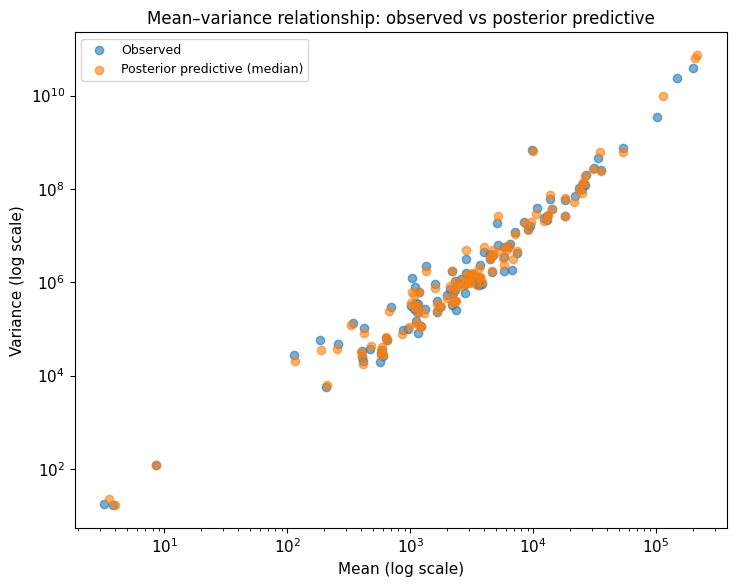

In [149]:
# Plot A: Mean–variance scatter (observed vs PPC median)
def plot_mean_variance_scatter(mv_df: pd.DataFrame, loglog: bool = True):
    x_obs = mv_df["obs_mean"].to_numpy()
    y_obs = mv_df["obs_var"].to_numpy()
    x_ppc = mv_df["ppc_mean_med"].to_numpy()
    y_ppc = mv_df["ppc_var_med"].to_numpy()

    plt.figure(figsize=(7.5, 6))

    # observed points
    plt.scatter(x_obs, y_obs, alpha=0.6, label="Observed")

    # PPC median points (same genes)
    plt.scatter(x_ppc, y_ppc, alpha=0.6, label="Posterior predictive (median)")

    # optional: connect each gene (helps interpretation)
    # for xo, yo, xp, yp in zip(x_obs, y_obs, x_ppc, y_ppc):
    #     plt.plot([xo, xp], [yo, yp], alpha=0.15)

    if loglog:
        plt.xscale("log")
        plt.yscale("log")
        plt.xlabel("Mean (log scale)")
        plt.ylabel("Variance (log scale)")
    else:
        plt.xlabel("Mean")
        plt.ylabel("Variance")

    plt.title("Mean–variance relationship: observed vs posterior predictive")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_mean_variance_scatter(mv_df, loglog=True)

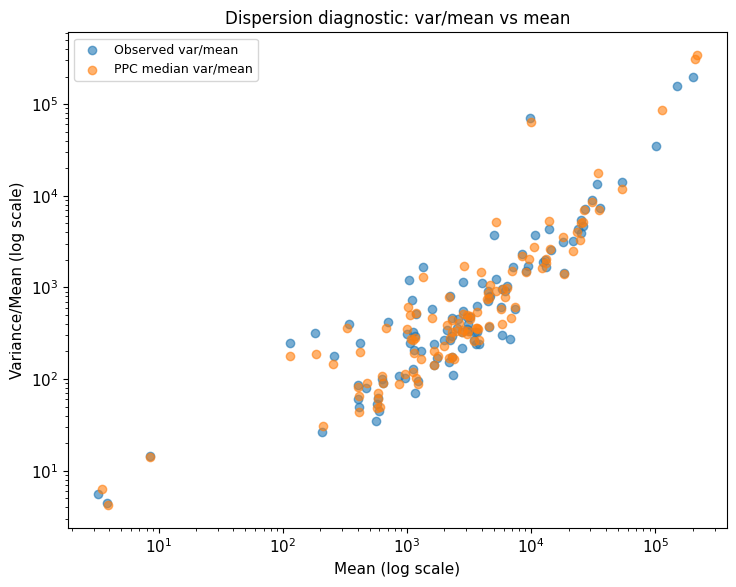

In [151]:
# Plot B: Dispersion curve (variance/mean vs mean)

def plot_dispersion_curve(mv_df: pd.DataFrame, logx: bool = True, logy: bool = True):
    obs_mean = mv_df["obs_mean"].to_numpy()
    obs_disp = mv_df["obs_var"].to_numpy() / np.maximum(obs_mean, 1e-12)

    ppc_mean = mv_df["ppc_mean_med"].to_numpy()
    ppc_disp = mv_df["ppc_var_med"].to_numpy() / np.maximum(ppc_mean, 1e-12)

    plt.figure(figsize=(7.5, 6))
    plt.scatter(obs_mean, obs_disp, alpha=0.6, label="Observed var/mean")
    plt.scatter(ppc_mean, ppc_disp, alpha=0.6, label="PPC median var/mean")

    if logx:
        plt.xscale("log")
        plt.xlabel("Mean (log scale)")
    else:
        plt.xlabel("Mean")

    if logy:
        plt.yscale("log")
        plt.ylabel("Variance/Mean (log scale)")
    else:
        plt.ylabel("Variance/Mean")

    plt.title("Dispersion diagnostic: var/mean vs mean")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_dispersion_curve(mv_df)
